# Schema for files

{
    "$schema": "http://json-schema.org/draft-04/schema#",
    "type": "object",
    "properties": {
        "name": {
            "type": "string"
        },
        "group": {
            "type": "string"
        },
        "metadata": {
            "type": "null"
        },
        "timers": {
            "type": "object",
            "properties": {
                "finished": {
                    "type": "string"
                },
                "started": {
                    "type": "string"
                },
                "vm-running": {
                    "type": "string"
                }
            },
            "required": [
                "finished",
                "started",
                "vm-running"
            ]
        },
        "metrics": {
            "type": "array",
            "items": [
                {
                    "type": "object",
                    "properties": {
                        "name": {
                            "type": "string"
                        },
                        "cpu": {
                            "type": "object",
                            "properties": {
                                "cores": {
                                    "type": "array",
                                    "items": [
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        },
                                        {
                                            "type": "number"
                                        }
                                    ]
                                },
                                "average": {
                                    "type": "number"
                                }
                            },
                            "required": [
                                "cores",
                                "average"
                            ]
                        },
                        "ram": {
                            "type": "number"
                        },
                        "disk": {
                            "type": "integer"
                        },
                        "timestamp": {
                            "type": "string"
                        }
                    },
                    "required": [
                        "name",
                        "cpu",
                        "ram",
                        "disk",
                        "timestamp"
                    ]
                }
            ]
        }
    },
    "required": [
        "name",
        "group",
        "metadata",
        "timers",
        "metrics"
    ]
}

In [233]:
# Install the required packages
%pip install matplotlib
%pip install Pillow
%pip install scipy
%pip install numpy
%pip install pandas
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [234]:
import os
import json
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib import lines
from scipy.interpolate import make_interp_spline
import pandas as pd
import seaborn as sns

import numpy as np
from itertools import groupby

RESULTS_DIR = 'results'
PLOTS_DIR = 'plots'

In [235]:
# Load results directory and parse out each test
def list_results():
    results = []

    results_files = os.listdir(RESULTS_DIR)
    for file in results_files:
        vmm, group, test, timestamp = file.removesuffix(".json").split('_', 3)
        
        # Parse content as json
        with open(f"{RESULTS_DIR}/{file}", "r") as f:
            content = f.read()
            json_content = json.loads(content)

        results.append({
            'vmm': vmm,
            'group': group,
            'test': test,
            # Parse from 2024-04-03-16-39-37 to datetime
            'timestamp': datetime.strptime(timestamp, "%Y-%m-%d-%H-%M-%S"),
            'data': json_content
        })


    return results       

results = list_results()

print(f"Found {len(results)} results")

Found 83 results


In [236]:
def merge_files(results, node_types):
    def merge_timers(results):
        merged_timers = {}
        for result in results:
            started = result['data']['timers']['started']
            for name, ts_list in result['data']['timers'].items():
                if name not in merged_timers:
                    merged_timers[name] = []

                diff = datetime.fromisoformat(ts_list) - datetime.fromisoformat(started)
                merged_timers[name].append(diff.total_seconds())

        for name, ts_list in merged_timers.items():
            merged_timers[name] = sum(ts_list) / len(ts_list)

        return merged_timers
        
    def combine_metrics(results):
        all_metrics = []
        for result in results:
            started = result['data']['timers']['started']

            for metric in result['data']['metrics']:
                metric['dt'] = (datetime.fromisoformat(metric['timestamp']) - datetime.fromisoformat(started)).total_seconds()
            

            all_metrics += result['data']['metrics']


        # Sort by timestamp
        all_metrics.sort(key=lambda x: x['timestamp'])

        node_groups = {}

        for metric in all_metrics:
            if metric['name'] not in node_groups:
                node_groups[metric['name']] = []

            node_groups[metric['name']].append(metric)

        node_groups = [(name, node_metrics) for name, node_metrics in node_groups.items() if any(node_type in name for node_type in node_types)]

        # Sort by x['data']
        for _, node_metrics in node_groups:
            node_metrics.sort(key=lambda x: x['dt'])

        return node_groups

    return (merge_timers(results), combine_metrics(results))


label = "kubevirt"
group = "create-each-type"
matches = [result for result in results if result['vmm'] == label and result['group'] == group]

merge_files(matches, ["control"])

({}, [])

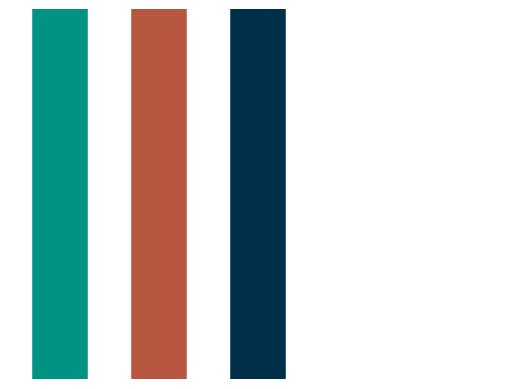

In [237]:
# three colors:
# 1. #009384
# 2. #b85741
# 3. #002f4a

colors = ["#009384", "#b85741", "#002f4a"]

def get_color(idx):
    return colors[idx % len(colors)]


def get_vmm_color(vmm):
    if vmm == "kubevirt":
        return get_color(0)
    elif vmm == "opennebula":
        return get_color(1)
    
    return get_color(2)

# Show colors in a plot next to each other
fig, ax = plt.subplots()
for idx, color in enumerate(colors):
    ax.add_line(lines.Line2D([idx * 0.2 + 0.1, idx * 0.2 + 0.1], [0, 1], color=color, linewidth=40))
plt.axis('off')
plt.show()

In [238]:
def _get_formatted_x_y(x, y):

    method = 'rolling_mean'
    
    if method == 'rolling_mean':
        window_size = int(0.15 * len(x)
)
        # if y is a list of lists, we need to apply rolling mean to each list
        if isinstance(y[0], list):
            y_new = []
            for yi in y:
                x = np.array(x[0:min(len(x), len(yi))])
                yi = np.array(yi[0:min(len(x), len(yi))])
                data = pd.DataFrame({'x': x, 'y': yi })
                data['y'] = data['y'].rolling(window=window_size, center=True).mean()
                y_new.append(data['y'])
        else:
            y_new = pd.Series(y).rolling(window=window_size).mean()

        return x, y_new
    
    return x, y

In [239]:
def plot_line(ax, x, y, color):
    x['data'], y['data'] = _get_formatted_x_y(x['data'], y['data'])
    ax.plot(x['data'], y['data'], color=color, label=y['label'],  linewidth=2)


def stack_plot(id, name, ax, x, y_list):
    x_res, y_list_res = _get_formatted_x_y(x['data'], [y['data'] for y in y_list])

    # Ensure x and all y's are the same length
    min_size = min([len(y) for y in y_list_res])
    min_size = min(min_size, len(x_res))

    x_res = x_res[:min_size]
    y_list_res = [y[:min_size] for y in y_list_res]
    
    colors=[get_color(id)]

    ax.stackplot(x_res, y_list_res, colors=colors, edgecolors=colors, alpha=0.7, labels=[name])


def plot_timers(ax, timers, min_y, max_y):
    for name, val in timers.items():
        # Skip started
        if name == 'started':
            continue            
        
        ax.plot([val, val],[min_y, max_y], label=name, linestyle='--')

In [240]:
def get_x_y(node_groups, utilizations, label_prefix):
    '''
    Returns multiple x axises (time in seconds since start, one for every node group) and multiple y axises (utilizations, same order as given)
    '''

    x_axises = []
    y_axises = []

    for name, node_metrics in node_groups:
        x_axis = []
        for metric in node_metrics:
            x_axis.append(metric['dt'])

        x_axises.append({"node": name, "data": x_axis})

    for utilization in utilizations:
        for name, node_metrics in node_groups:
            y_axis = []
            for metric in node_metrics:
                if utilization == 'cpu':
                    y_axis.append(metric[utilization]['average'] * 100)
                else:
                    y_axis.append(metric[utilization] * 100)
        
            y_axises.append({"node": name, "data": y_axis, "label": label_prefix + " " + utilization})
        
    return x_axises, y_axises

def plot_results(vmms, group, test, node_types, utiliazations, stackplot: bool = False, filename: str = None):
    # Remove any utilization that is not 'cpu', 'ram' or 'disk'
    utiliazations = [utiliazation for utiliazation in utiliazations if utiliazation in ['cpu', 'ram', 'disk']]
    if len(utiliazations) == 0:
        print(f"No valid utilizations found")
        return

    name = f"{group}/{test}"

    fig, ax = plt.subplots()
    ax.set_title(f"{test} ({', '.join(utiliazations)})")
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Utilization (%)')

    if len(vmms) > 1:
        print(f"Plotting {name} for {', '.join(vmms)}")
    else:   
        print(f"Plotting {name} for {vmms[0]}")

    # 1. Find result with group and test, choose latest if multiple
    for vmm_idx, vmm in enumerate(vmms):
        matches = [result for result in results if result['vmm'] == vmm and result['group'] == group and result['test'] == test]
        if len(matches) == 0:
            print(f"No results found for {vmm}/{group}/{test}")
            return
        
        print(f"Found {len(matches)} results for {vmm}/{group}/{test}")
        
        timers, node_groups = merge_files(matches, node_types)
    
        x_axises, y_axises = get_x_y(node_groups, utiliazations, vmm)
        x_timers = timers

        if stackplot:
            stack_plot(vmm_idx, vmm, ax, x_axises[0], y_axises)
        else:
            for plot_idx, x_axis in enumerate(x_axises):
                
                # Find all its corresponding y axises
                y_axises = [y_axises[i] for i in range(plot_idx, len(y_axises), len(x_axises))]
                for y_idx, y_axis in enumerate(y_axises):
                    color = get_vmm_color(vmm) if len(vmms) > 1 else get_color(y_idx)
                    plot_line(ax, x_axis, y_axis, color)
        

    ax.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
    plt.show()

    if filename:
        if not os.path.exists(PLOTS_DIR):
            os.makedirs(PLOTS_DIR)
        fig.savefig(os.path.join(PLOTS_DIR, filename), bbox_inches='tight')

## Create each type

Plotting create-vm/create-small for kubevirt
Found 7 results for kubevirt/create-vm/create-small


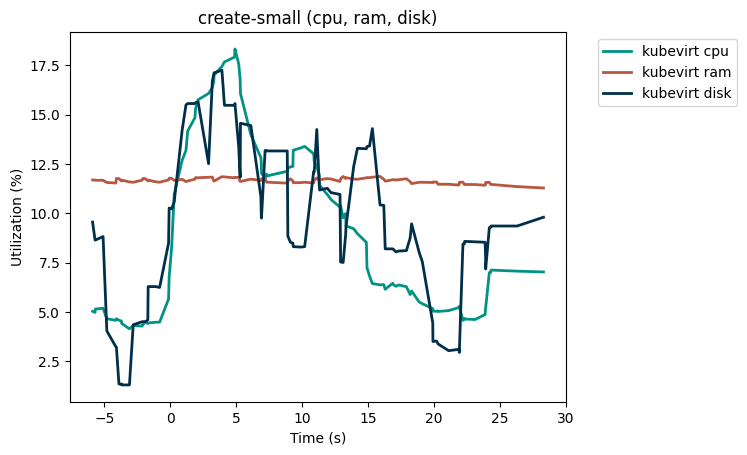

Plotting create-vm/create-small for opennebula
Found 6 results for opennebula/create-vm/create-small


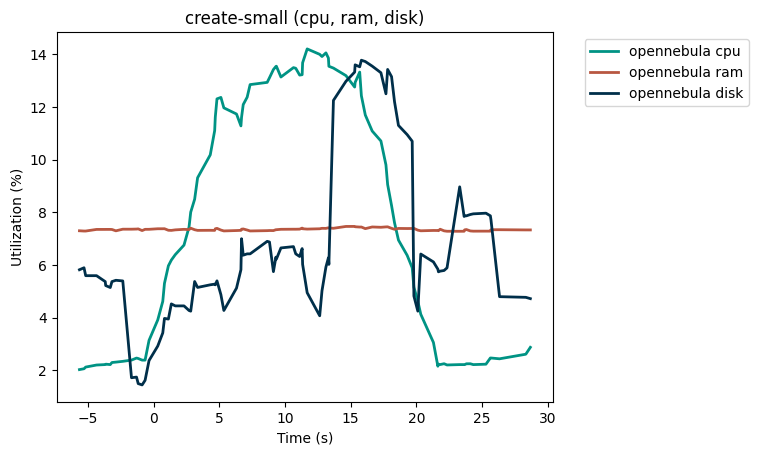

Plotting create-vm/create-many for kubevirt, opennebula
Found 4 results for kubevirt/create-vm/create-many
Found 3 results for opennebula/create-vm/create-many


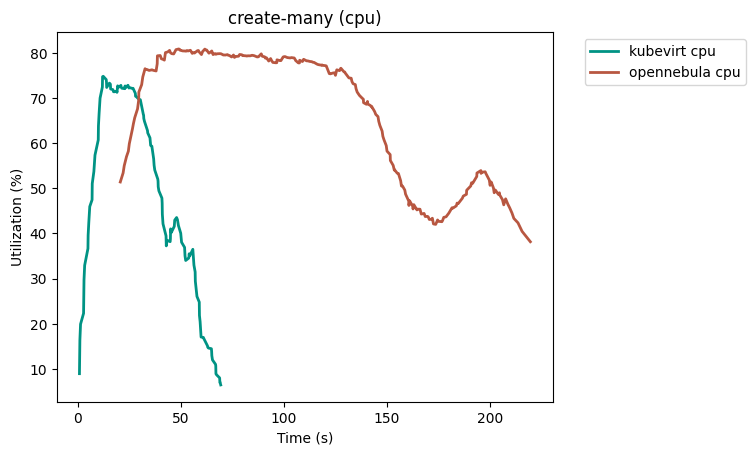

Plotting create-vm/create-many for kubevirt, opennebula
Found 4 results for kubevirt/create-vm/create-many
Found 3 results for opennebula/create-vm/create-many


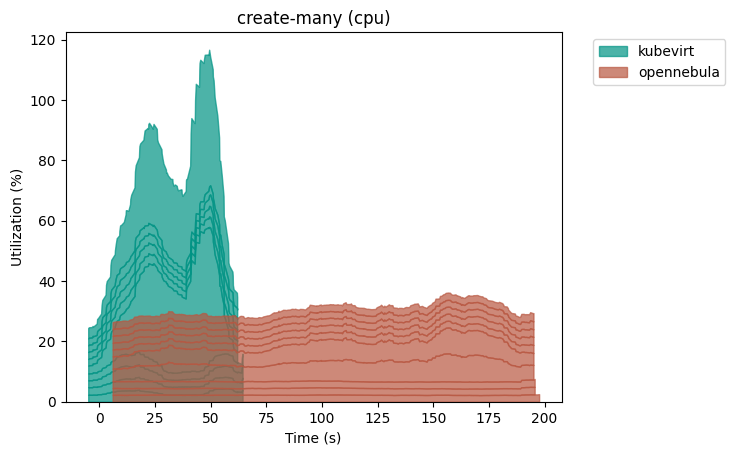

Plotting create-vm/create-many for kubevirt, opennebula
Found 4 results for kubevirt/create-vm/create-many
Found 3 results for opennebula/create-vm/create-many


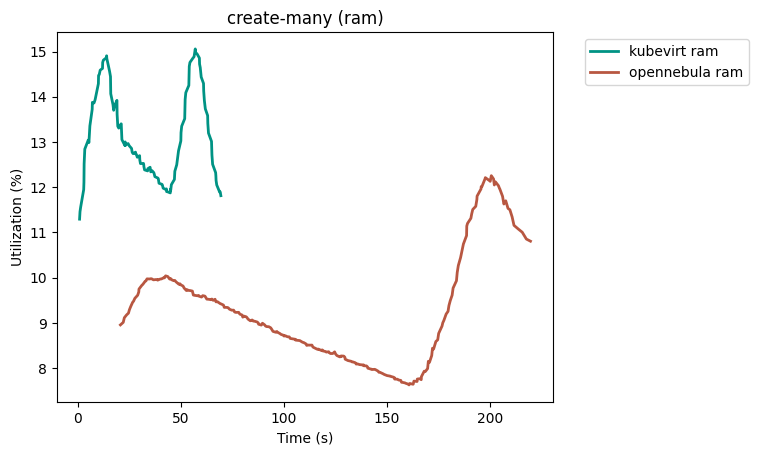

Plotting create-vm/create-many for kubevirt, opennebula
Found 4 results for kubevirt/create-vm/create-many
Found 3 results for opennebula/create-vm/create-many


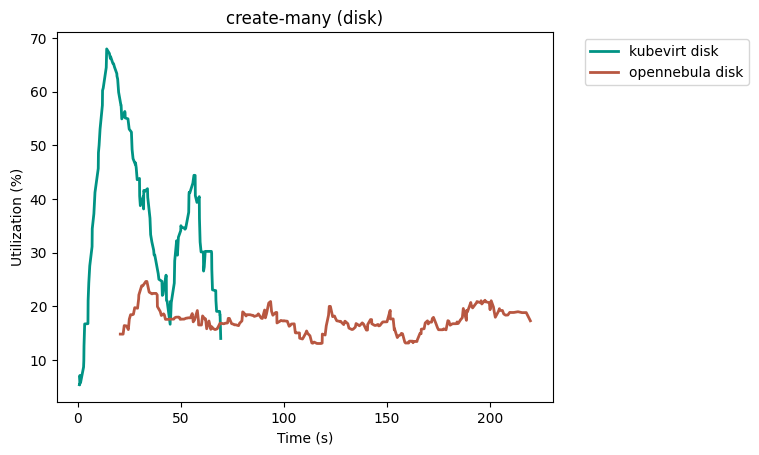

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 4 results for kubevirt/live-migrate/live-migrate
Found 3 results for opennebula/live-migrate/live-migrate


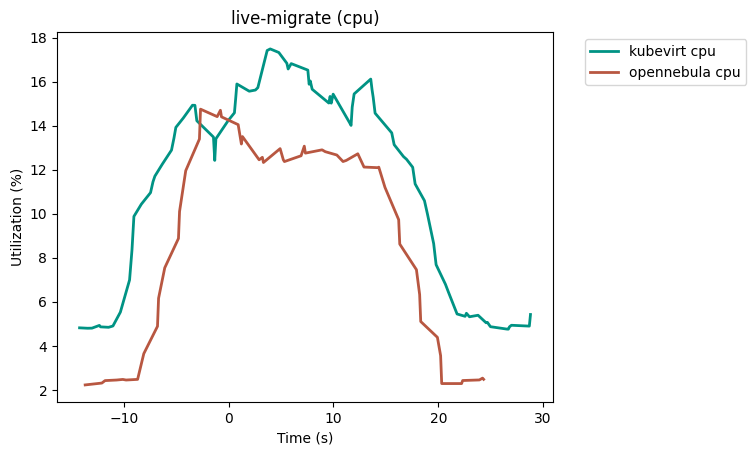

Plotting live-migrate/live-migrate for kubevirt, opennebula
Found 4 results for kubevirt/live-migrate/live-migrate
Found 3 results for opennebula/live-migrate/live-migrate


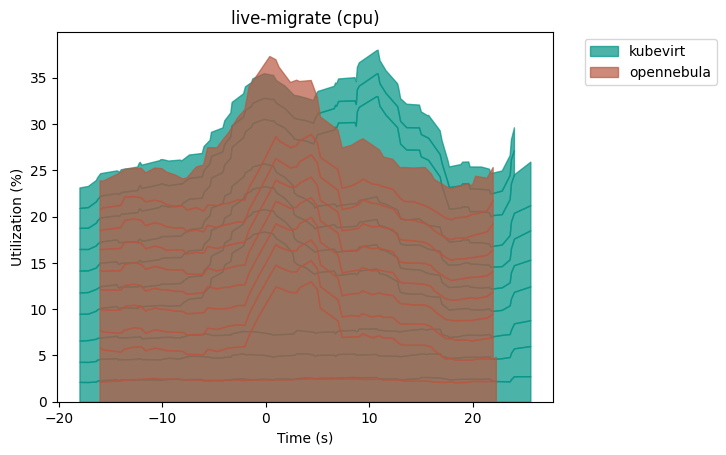

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 4 results for kubevirt/live-migrate/live-migrate-many
Found 3 results for opennebula/live-migrate/live-migrate-many


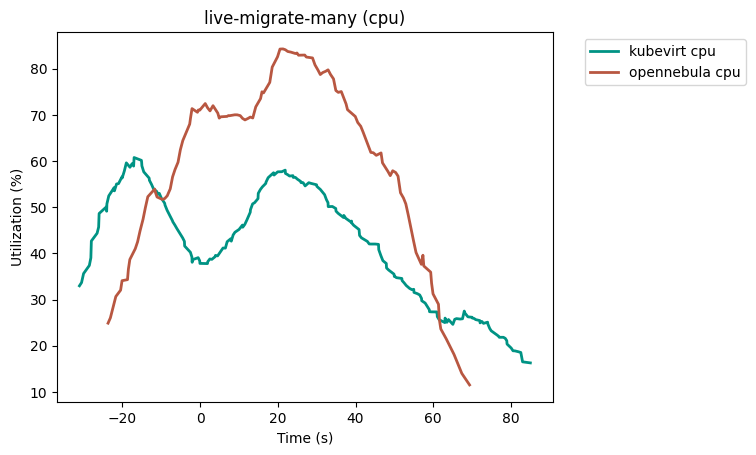

Plotting live-migrate/live-migrate-many for kubevirt, opennebula
Found 4 results for kubevirt/live-migrate/live-migrate-many
Found 3 results for opennebula/live-migrate/live-migrate-many


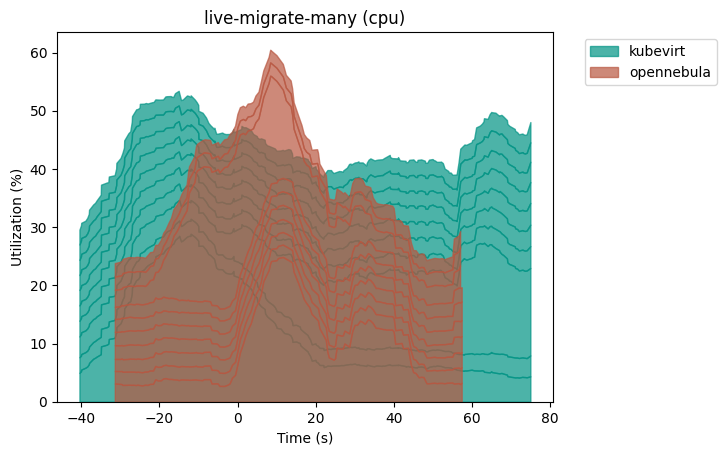

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 3 results for kubevirt/scale-cluster/scale-cluster
Found 3 results for opennebula/scale-cluster/scale-cluster


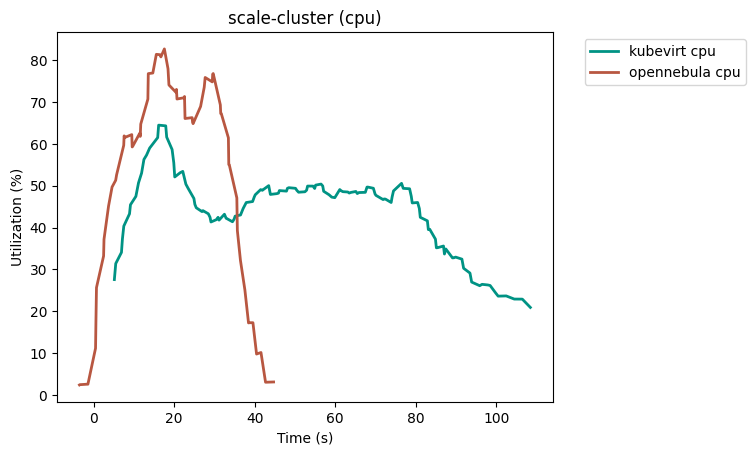

Plotting scale-cluster/scale-cluster for kubevirt, opennebula
Found 3 results for kubevirt/scale-cluster/scale-cluster
Found 3 results for opennebula/scale-cluster/scale-cluster


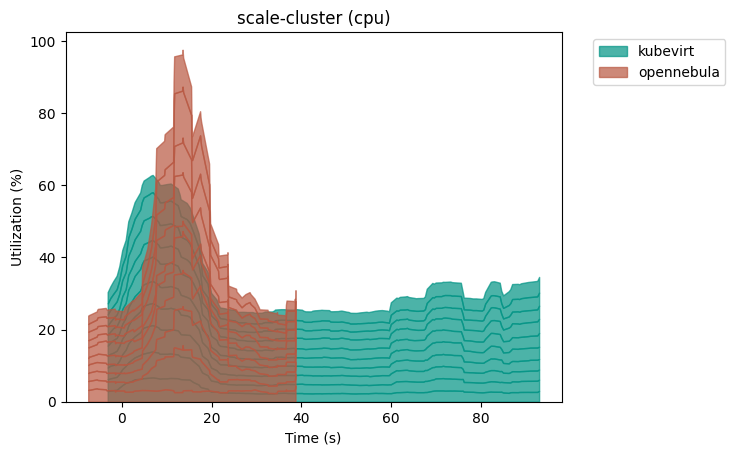

Plotting scale-cluster/scale-cluster-with-vms for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster-with-vms
No results found for opennebula/scale-cluster/scale-cluster-with-vms
Plotting scale-cluster/scale-cluster-with-vms for kubevirt, opennebula
Found 4 results for kubevirt/scale-cluster/scale-cluster-with-vms
No results found for opennebula/scale-cluster/scale-cluster-with-vms


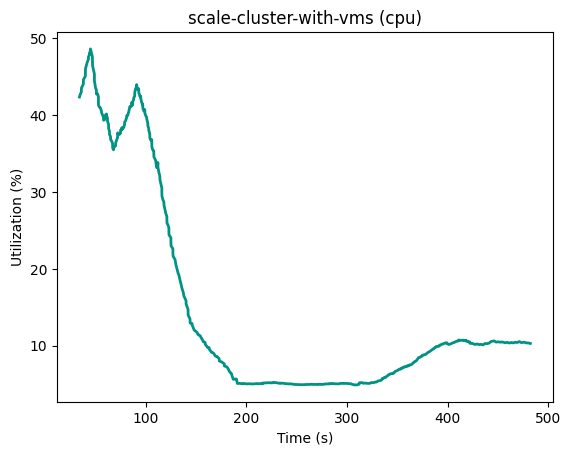

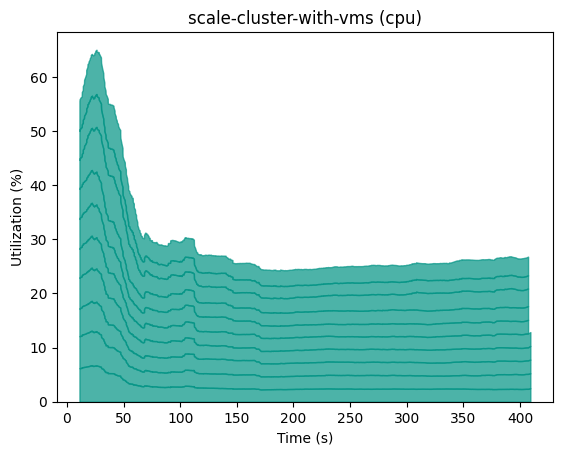

In [242]:
# Create VMs
plot_results(['kubevirt'],'create-vm', 'create-small', ['control'], ['cpu', 'ram', 'disk'], filename='create-many_cpu.pdf')
plot_results(['opennebula'],'create-vm', 'create-small', ['control'], ['cpu', 'ram', 'disk'], filename='create-many_cpu.pdf')

plot_results(['kubevirt', 'opennebula'],'create-vm', 'create-many', ['control'], ['cpu'], filename='create-many_cpu.pdf')
plot_results(['kubevirt', 'opennebula'],'create-vm', 'create-many', ['worker'], ['cpu'], filename='create-many_cpu_worker.pdf', stackplot=True)

plot_results(['kubevirt', 'opennebula'],'create-vm', 'create-many', ['control'], ['ram'], filename='create-many_ram.pdf')
plot_results(['kubevirt', 'opennebula'],'create-vm', 'create-many', ['control'], ['disk'], filename='create-many_disk.pdf')

# Live migrate
plot_results(['kubevirt', 'opennebula'],'live-migrate', 'live-migrate', ['control'], ['cpu'], filename='live-migrate_cpu.pdf')
plot_results(['kubevirt', 'opennebula'],'live-migrate', 'live-migrate', ['worker'], ['cpu'], filename='live-migrate_cpu_worker.pdf', stackplot=True)

plot_results(['kubevirt', 'opennebula'],'live-migrate', 'live-migrate-many', ['control'], ['cpu'], filename='live-migrate-many_cpu.pdf')
plot_results(['kubevirt', 'opennebula'],'live-migrate', 'live-migrate-many', ['worker'], ['cpu'], filename='live-migrate-many_cpu_worker.pdf', stackplot=True)

# Scale cluster
plot_results(['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster', ['control'], ['cpu'], filename='scale-cluster_cpu.pdf')
plot_results(['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster', ['worker'], ['cpu'], filename='scale-cluster_cpu_worker.pdf', stackplot=True)

plot_results(['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster-with-vms', ['control'], ['cpu'], filename='scale-cluster-with-vms_cpu.pdf')
plot_results(['kubevirt', 'opennebula'],'scale-cluster', 'scale-cluster-with-vms', ['worker'], ['cpu'], filename='scale-cluster-with-vms_cpu_worker.pdf', stackplot=True)